In [190]:
import numpy as np
import pandas as pd
import joblib
from scipy.signal import welch
import matplotlib.pyplot as plt

### Helper Functions

In [191]:
def get_frequency(flux, fs):
    """
    Find the frequency of a planet's orbit by using signal.welch to calculate the frequency at 
    which the planet passes in front of the star, causing the flux (as measured from the kepler 
    telescope) to decrease

    Parameters
    ---------
    flux: np.array or pd.Series
        measured brightness of a star at different time points
    fs: float
        sampling frequency at which flux measurements were taken in days

    Returns
    ---------
    frequency: float
        the frequency of a planet's orbit in days
    power: float
        the percentage of all power contained in frequency
    """
    # Get frequencies and corresponding powers
    freqs, psd = welch(flux[~np.isnan(flux)], fs=fs)

    # Find the frequency with the most power
    highest = np.argmax(psd)
    power = psd[highest] / np.sum(psd)
    frequency = freqs[highest]

    return frequency, power


In [192]:
def get_solar_mass(radius, surface_gravity):
    """
    Compute the mass of a star in solar mass (1.988416 x 10^30 kg) from its radius and surface gravity

    Parameters
    ---------
    radius: float
        radius of a star in solar radii (695,700 km)
    surface_gravity: float
        surface gravity of a star in log_10(cm * s^-2)
    
    Returns
    ---------
    mass: float
        the mass of the star in solar mass(1.988416 x 10^30 kg)
    """
    # Convert surface gravity to m/s^2 and radius to m^2
    sg = 10 ** (surface_gravity - 2)
    rad = radius * 695700 * 1000

    # Calculate star mass
    G = 6.674 * 10**(-11)
    m = sg * rad**2 / G

    # Convert m to solar mass
    mass = m / (1.988416 * 10**(30))

    return mass

In [193]:
def compute_radius(frequency, mass):
    """
    Compute the radius of a planet's orbit based on its frequency

    Parameters
    ---------
    frequency: float
        the frequency of a planet's orbit in days
    mass: float
        the mass of the orbited star in solar mass (1.988416 x 10^30 kg)

    Returns
    ---------
    radius: float
        the radius of a planet's orbit in solar radii (695700 km)
    """
    # Get gravitational constant, mass in kg, and compute radius
    G_const = 6.6743 * 10**(-11)
    M = mass * 1.988416 * 10**30
    f = frequency / (24 * 3600)
    radius = np.cbrt(G_const * M / (4 * np.pi**2 * f**2))

    # Convert from meters to solar radii
    radius = radius / (1000 * 695700)

    return radius

In [194]:
def calculate_habitable_zone(radius, eff_temp):
    """
    Compute the upper and lower bounds of a star's habitable zone

    Parameters
    ---------
    radius: float
        the radius of a star in solar radii (695700 km)
    eff_temp: float
        the stellar effective temperature of a star in Kelvin
    
    Returns
    ---------
    lower: float
        the lower bound of the habitable zone in solar radii (695700 km)
    upper: float
        the upper bound of the habitable zone in solar radii (695700 km)
    """
    stephen_boltzmann = 5.67 * 10**(-8)
    # Convert radius to meters
    r = radius * 695700 * 1000

    # Calculate luminosity of the star & convert to solar units
    l = 4 * np.pi * r**2 * stephen_boltzmann * eff_temp**4
    l = l / (3.838 * 10**26)

    # Calculate lower and upper bounds
    lower = np.sqrt(l / 1.1) * 215.032
    upper = np.sqrt(l / 0.53) * 215.032

    return lower, upper


### Load in Data

In [195]:
df = pd.read_csv('cumulative.csv', delimiter=',')
stars = [11446443, 11414511, 9579641, 10583181, 8299955]

# Extract period of reported planets
periods = df.set_index('kepid').loc[stars, 'koi_period']
periods[9579641] = periods[9579641].mean()
periods = periods.drop_duplicates()

# Extract surface gravity and star radius to calculate star mass
surface_gravity = df.set_index('kepid').loc[stars, 'koi_slogg'].drop_duplicates()
star_radius = df.set_index('kepid').loc[stars, 'koi_srad'].drop_duplicates()
star_mass = pd.DataFrame([get_solar_mass(star_radius[lab], surface_gravity[lab]) for lab in stars], index=stars, columns=['koi_smass'])

# Extract effective temperature to calculate inhabitable zone
effective_temp = df.set_index('kepid').loc[stars, 'koi_steff'].drop_duplicates()

In [196]:
light_curve_dict = joblib.load("5_stars.joblib")

### 11446443

In [197]:
# Extract time, flux, and flux_error from the dictionary
star = 11446443
t = light_curve_dict[star]['time']
vals = np.array(light_curve_dict[star]['flux'].data)
err = np.array(light_curve_dict[star]['flux_err'].data)

Max: 0.009535885801597033, Min: 0.0006809148981119506


Text(0, 0.5, 'Number of Occurences')

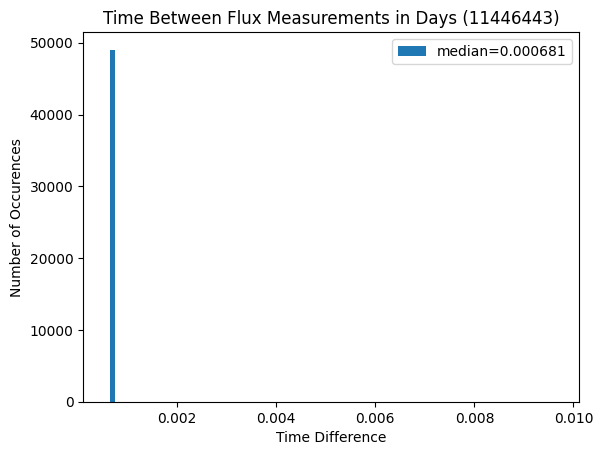

In [198]:
# Find how often measurements are taken
diffs = np.diff(t)
print(f"Max: {np.max(diffs)}, Min: {np.min(diffs)}")

med = np.median(diffs)
plt.hist(diffs, bins=100, range=(np.min(diffs) - np.std(diffs), np.max(diffs) + np.std(diffs)), label=f'median={round(med, 6)}')
plt.title(f"Time Between Flux Measurements in Days ({star})")
plt.legend()
plt.xlabel("Time Difference")
plt.ylabel("Number of Occurences")

In [199]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days = 1 / med
print(f"Sampling frequency: {freq_days}")

Sampling frequency: 1468.1707784040304


Text(0, 0.5, 'Power')

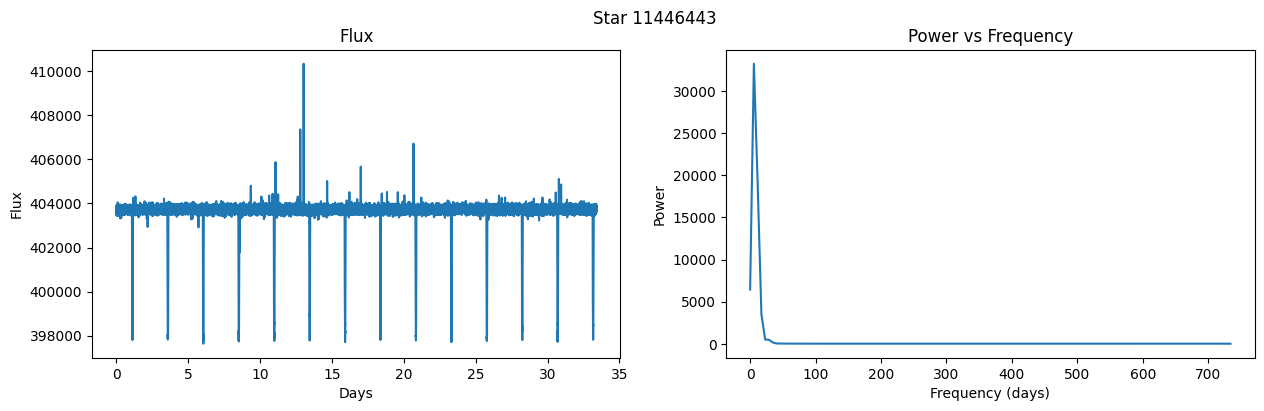

In [200]:
freqs, psd = welch(vals[~np.isnan(vals)], fs=freq_days)
timesteps = np.arange(len(vals)) * med

plt.figure(figsize=(15, 4))
plt.suptitle(f"Star {star}")

plt.subplot(1, 2, 1)
plt.plot(timesteps, vals)
plt.title(f"Flux")
plt.xlabel("Days")
plt.ylabel("Flux")

plt.subplot(1, 2, 2)
plt.plot(freqs, psd)
plt.title(f"Power vs Frequency")
plt.xlabel("Frequency (days)")
plt.ylabel("Power")

In [201]:
# Get frequency of star
frequency, power = get_frequency(vals, freq_days)

# Check that my period estimation is similar to recorded period
print(f"Calculated period: {round(1/frequency, 3)} days, Reported period: {round(periods[star], 3)} days")

# Compute the radius
radius = compute_radius(frequency, star_mass.loc[11446443, 'koi_smass'])
radius2 = compute_radius(1 / periods[star], star_mass.loc[11446443, 'koi_smass'])
print(f"signal.welch() orbital radius: {round(radius, 3)} solar radii, orbital radius using given period: {round(radius2, 3)} solar radii")

Calculated period: 0.174 days, Reported period: 2.471 days
signal.welch() orbital radius: 1.301 solar radii, orbital radius using given period: 7.615 solar radii


In [202]:
# Calculate habitable zone
lower, upper = calculate_habitable_zone(radius, effective_temp[star])
lower2, upper2 = calculate_habitable_zone(radius2, effective_temp[star])

print(f"Habitable Zone (using signal.welch()): {round(lower, 2)} solar radii, {round(upper, 2)} solar radii")
print(f"Habitable Zone (using given period): {round(lower2, 2)} solar radii, {round(upper2, 2)} solar radii")

Habitable Zone (using signal.welch()): 270.73 solar radii, 390.03 solar radii
Habitable Zone (using given period): 1585.24 solar radii, 2283.78 solar radii


**UNINHABITABLE**

### 11414511

In [203]:
# Extract time, flux, and flux_error from the dictionary
star = 11414511
t = light_curve_dict[star]['time']
vals = np.array(light_curve_dict[star]['flux'].data)
err = np.array(light_curve_dict[star]['flux_err'].data)

Max: 0.04086868708691327, Min: 0.020433656121895183


Text(0, 0.5, 'Number of Occurences')

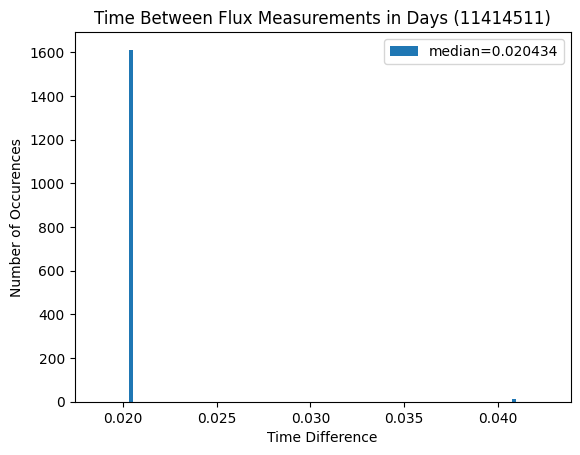

In [204]:
# Find how often measurements are taken
diffs = np.diff(t)
print(f"Max: {np.max(diffs)}, Min: {np.min(diffs)}")

med = np.median(diffs)
plt.hist(diffs, bins=100, range=(np.min(diffs) - np.std(diffs), np.max(diffs) + np.std(diffs)), label=f'median={round(med, 6)}')
plt.title(f"Time Between Flux Measurements in Days ({star})")
plt.legend()
plt.xlabel("Time Difference")
plt.ylabel("Number of Occurences")

In [205]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days = 1 / med
print(f"Sampling frequency: {freq_days}")

Sampling frequency: 48.937286637467025


Text(0, 0.5, 'Power')

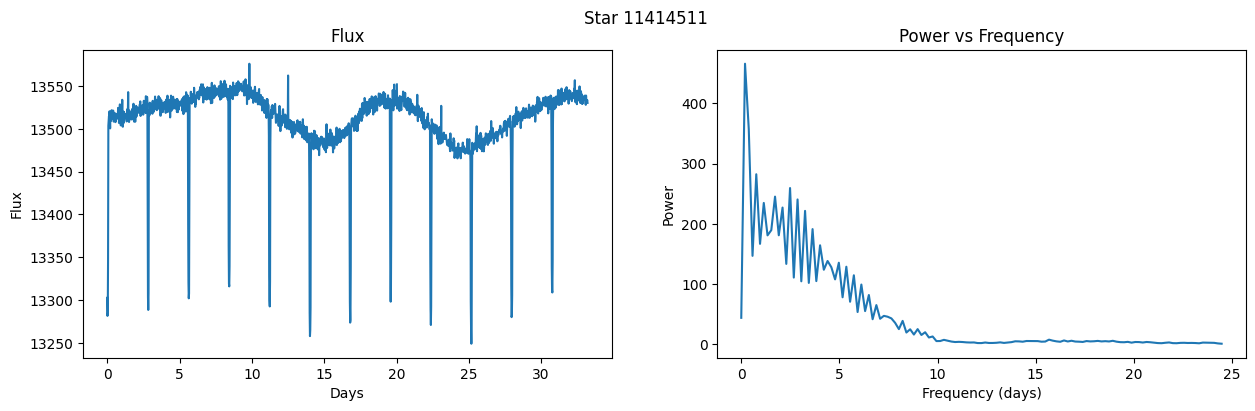

In [206]:
freqs, psd = welch(vals[~np.isnan(vals)], fs=freq_days)
timesteps = np.arange(len(vals)) * med

plt.figure(figsize=(15, 4))
plt.suptitle(f"Star {star}")

plt.subplot(1, 2, 1)
plt.plot(timesteps, vals)
plt.title(f"Flux")
plt.xlabel("Days")
plt.ylabel("Flux")

plt.subplot(1, 2, 2)
plt.plot(freqs, psd)
plt.title(f"Power vs Frequency")
plt.xlabel("Frequency (days)")
plt.ylabel("Power")

In [207]:
# Get frequency of star
frequency, power = get_frequency(vals, freq_days)

# Check that my period estimation is similar to recorded period
print(f"Calculated period: {round(1/frequency, 3)} days, Reported period: {round(periods[star], 3)} days")

# Compute the radius
radius = compute_radius(frequency, star_mass.loc[11446443, 'koi_smass'])
radius2 = compute_radius(1 / periods[star], star_mass.loc[11446443, 'koi_smass'])
print(f"signal.welch() orbital radius: {round(radius, 3)} solar radii, orbital radius using given period: {round(radius2, 3)} solar radii")

Calculated period: 5.231 days, Reported period: 2.817 days
signal.welch() orbital radius: 12.557 solar radii, orbital radius using given period: 8.31 solar radii


In [208]:
# Calculate habitable zone
lower, upper = calculate_habitable_zone(radius, effective_temp[star])
lower2, upper2 = calculate_habitable_zone(radius2, effective_temp[star])

print(f"Habitable Zone (using signal.welch()): {round(lower, 2)} solar radii, {round(upper, 2)} solar radii")
print(f"Habitable Zone (using given period): {round(lower2, 2)} solar radii, {round(upper2, 2)} solar radii")

Habitable Zone (using signal.welch()): 2361.62 solar radii, 3402.27 solar radii
Habitable Zone (using given period): 1562.97 solar radii, 2251.69 solar radii


**UNINHABITABLE**

### 9579641

In [209]:
# Extract time, flux, and flux_error from the dictionary
star = 9579641
t = light_curve_dict[star]['time']
vals = np.array(light_curve_dict[star]['flux'].data)
err = np.array(light_curve_dict[star]['flux_err'].data)

Max: 0.04086863039265154, Min: 0.020433528065041173


Text(0, 0.5, 'Number of Occurences')

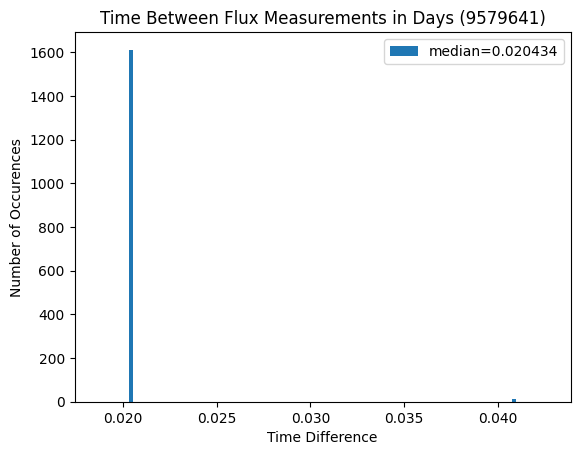

In [210]:
# Find how often measurements are taken
diffs = np.diff(t)
print(f"Max: {np.max(diffs)}, Min: {np.min(diffs)}")

med = np.median(diffs)
plt.hist(diffs, bins=100, range=(np.min(diffs) - np.std(diffs), np.max(diffs) + np.std(diffs)), label=f'median={round(med, 6)}')
plt.title(f"Time Between Flux Measurements in Days ({star})")
plt.legend()
plt.xlabel("Time Difference")
plt.ylabel("Number of Occurences")

In [211]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days = 1 / med
print(f"Sampling frequency: {freq_days}")

Sampling frequency: 48.93750187059898


Text(0, 0.5, 'Power')

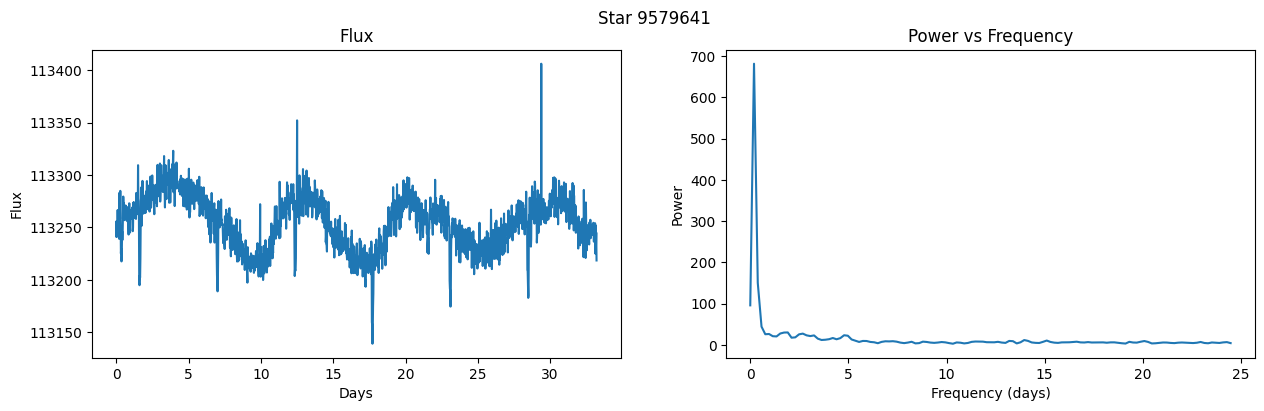

In [212]:
freqs, psd = welch(vals[~np.isnan(vals)], fs=freq_days)
timesteps = np.arange(len(vals)) * med

plt.figure(figsize=(15, 4))
plt.suptitle(f"Star {star}")

plt.subplot(1, 2, 1)
plt.plot(timesteps, vals)
plt.title(f"Flux")
plt.xlabel("Days")
plt.ylabel("Flux")

plt.subplot(1, 2, 2)
plt.plot(freqs, psd)
plt.title(f"Power vs Frequency")
plt.xlabel("Frequency (days)")
plt.ylabel("Power")

In [213]:
# Get frequency of star
frequency, power = get_frequency(vals, freq_days)

# Check that my period estimation is similar to recorded period
print(f"Calculated period: {round(1/frequency, 3)} days, Reported period: {round(periods[star], 3)} days")

# Compute the radius
radius = compute_radius(frequency, star_mass.loc[11446443, 'koi_smass'])
radius2 = compute_radius(1 / periods[star], star_mass.loc[11446443, 'koi_smass'])
print(f"signal.welch() orbital radius: {round(radius, 3)} solar radii, orbital radius using given period: {round(radius2, 3)} solar radii")

Calculated period: 5.231 days, Reported period: 5.325 days
signal.welch() orbital radius: 12.557 solar radii, orbital radius using given period: 12.706 solar radii


In [214]:
# Calculate habitable zone
lower, upper = calculate_habitable_zone(radius, effective_temp[star])
lower2, upper2 = calculate_habitable_zone(radius2, effective_temp[star])

print(f"Habitable Zone (using signal.welch()): {round(lower, 2)} solar radii, {round(upper, 2)} solar radii")
print(f"Habitable Zone (using given period): {round(lower2, 2)} solar radii, {round(upper2, 2)} solar radii")

Habitable Zone (using signal.welch()): 2577.21 solar radii, 3712.86 solar radii
Habitable Zone (using given period): 2607.84 solar radii, 3756.98 solar radii


**UNINHABITABLE**

### 10583181

In [215]:
# Extract time, flux, and flux_error from the dictionary
star = 10583181
t = light_curve_dict[star]['time']
vals = np.array(light_curve_dict[star]['flux'].data)
err = np.array(light_curve_dict[star]['flux_err'].data)

Max: 0.04086843842378585, Min: 0.02043342282559024


Text(0, 0.5, 'Number of Occurences')

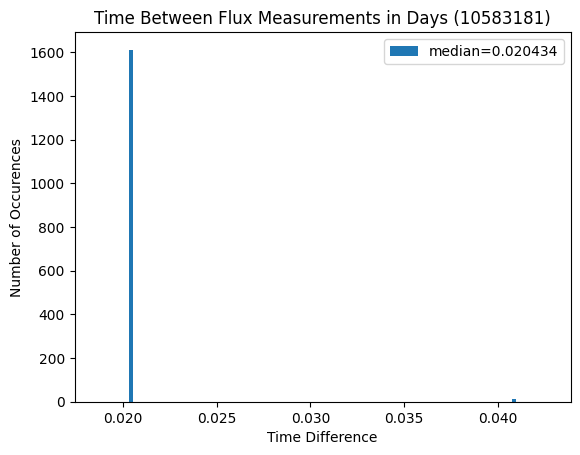

In [216]:
# Find how often measurements are taken
diffs = np.diff(t)
print(f"Max: {np.max(diffs)}, Min: {np.min(diffs)}")

med = np.median(diffs)
plt.hist(diffs, bins=100, range=(np.min(diffs) - np.std(diffs), np.max(diffs) + np.std(diffs)), label=f'median={round(med, 6)}')
plt.title(f"Time Between Flux Measurements in Days ({star})")
plt.legend()
plt.xlabel("Time Difference")
plt.ylabel("Number of Occurences")

In [217]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days = 1 / med
print(f"Sampling frequency: {freq_days}")

Sampling frequency: 48.937741919110216


Text(0, 0.5, 'Power')

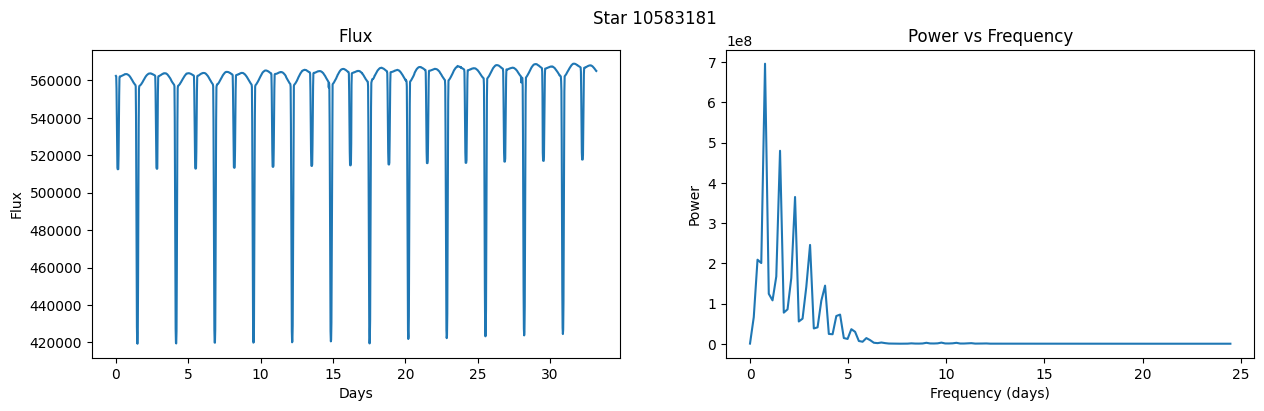

In [218]:
freqs, psd = welch(vals[~np.isnan(vals)], fs=freq_days)
timesteps = np.arange(len(vals)) * med

plt.figure(figsize=(15, 4))
plt.suptitle(f"Star {star}")

plt.subplot(1, 2, 1)
plt.plot(timesteps, vals)
plt.title(f"Flux")
plt.xlabel("Days")
plt.ylabel("Flux")

plt.subplot(1, 2, 2)
plt.plot(freqs, psd)
plt.title(f"Power vs Frequency")
plt.xlabel("Frequency (days)")
plt.ylabel("Power")

In [219]:
# Get frequency of star
frequency, power = get_frequency(vals, freq_days)

# Check that my period estimation is similar to recorded period
print(f"Calculated period: {round(1/frequency, 3)} days, Reported period: {round(periods[star], 3)} days")

# Compute the radius
radius = compute_radius(frequency, star_mass.loc[11446443, 'koi_smass'])
radius2 = compute_radius(1 / periods[star], star_mass.loc[11446443, 'koi_smass'])
print(f"signal.welch() orbital radius: {round(radius, 3)} solar radii, orbital radius using given period: {round(radius2, 3)} solar radii")

Calculated period: 1.308 days, Reported period: 2.696 days
signal.welch() orbital radius: 4.983 solar radii, orbital radius using given period: 8.072 solar radii


In [220]:
# Calculate habitable zone
lower, upper = calculate_habitable_zone(radius, effective_temp[star])
lower2, upper2 = calculate_habitable_zone(radius2, effective_temp[star])

print(f"Habitable Zone (using signal.welch()): {round(lower, 2)} solar radii, {round(upper, 2)} solar radii")
print(f"Habitable Zone (using given period): {round(lower2, 2)} solar radii, {round(upper2, 2)} solar radii")

Habitable Zone (using signal.welch()): 1282.76 solar radii, 1848.01 solar radii
Habitable Zone (using given period): 2077.98 solar radii, 2993.64 solar radii


**UNINHABITABLE**

### 8299955

In [221]:
# Extract time, flux, and flux_error from the dictionary
star = 8299955
t = light_curve_dict[star]['time']
vals = np.array(light_curve_dict[star]['flux'].data)
err = np.array(light_curve_dict[star]['flux_err'].data)

Max: 0.04086883994023083, Min: 0.020433639590919483


Text(0, 0.5, 'Number of Occurences')

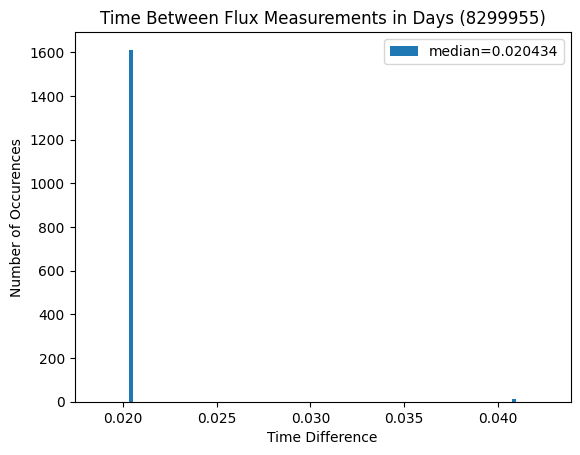

In [222]:
# Find how often measurements are taken
diffs = np.diff(t)
print(f"Max: {np.max(diffs)}, Min: {np.min(diffs)}")

med = np.median(diffs)
plt.hist(diffs, bins=100, range=(np.min(diffs) - np.std(diffs), np.max(diffs) + np.std(diffs)), label=f'median={round(med, 6)}')
plt.title(f"Time Between Flux Measurements in Days ({star})")
plt.legend()
plt.xlabel("Time Difference")
plt.ylabel("Number of Occurences")

In [223]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days = 1 / med
print(f"Sampling frequency: {freq_days}")

Sampling frequency: 48.93723533865798


Text(0, 0.5, 'Power')

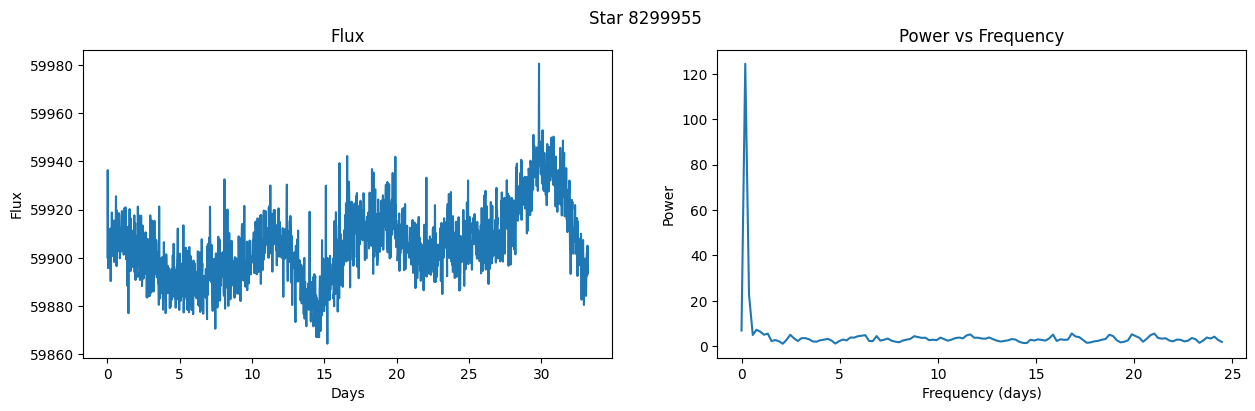

In [224]:
freqs, psd = welch(vals[~np.isnan(vals)], fs=freq_days)
timesteps = np.arange(len(vals)) * med

plt.figure(figsize=(15, 4))
plt.suptitle(f"Star {star}")

plt.subplot(1, 2, 1)
plt.plot(timesteps, vals)
plt.title(f"Flux")
plt.xlabel("Days")
plt.ylabel("Flux")

plt.subplot(1, 2, 2)
plt.plot(freqs, psd)
plt.title(f"Power vs Frequency")
plt.xlabel("Frequency (days)")
plt.ylabel("Power")

In [225]:
# Get frequency of star
frequency, power = get_frequency(vals, freq_days)

# Check that my period estimation is similar to recorded period
print(f"Calculated period: {round(1/frequency, 3)} days, Reported period: {round(periods[star], 3)} days")

# Compute the radius
radius = compute_radius(frequency, star_mass.loc[11446443, 'koi_smass'])
radius2 = compute_radius(1 / periods[star], star_mass.loc[11446443, 'koi_smass'])
print(f"signal.welch() orbital radius: {round(radius, 3)} solar radii, orbital radius using given period: {round(radius2, 3)} solar radii")

Calculated period: 5.231 days, Reported period: 2.683 days
signal.welch() orbital radius: 12.557 solar radii, orbital radius using given period: 8.045 solar radii


In [226]:
# Calculate habitable zone
lower, upper = calculate_habitable_zone(radius, effective_temp[star])
lower2, upper2 = calculate_habitable_zone(radius2, effective_temp[star])

print(f"Habitable Zone (using signal.welch()): {round(lower, 2)} solar radii, {round(upper, 2)} solar radii")
print(f"Habitable Zone (using given period): {round(lower2, 2)} solar radii, {round(upper2, 2)} solar radii")

Habitable Zone (using signal.welch()): 2947.29 solar radii, 4246.02 solar radii
Habitable Zone (using given period): 1888.33 solar radii, 2720.42 solar radii


**UNINHABITABLE**

### Extra Code Cells

In [227]:
# from lightkurve import search_lightcurve
# import numpy as np
# import joblib

In [228]:
# subset_collectionq1 = {}
# ids = [11446443] #, 11414511, 9579641, 10583181, 8299955]
# # Given the slowness of the download we start with only a random subset
# for kid in ids:
#     # The try and except is for larger downloads that might have network troubles
#     try:
#         print(f"ID {kid}")
#         lc = search_lightcurve(f"KIC {kid}", quarter=1)
#         # Only download if data was found
#         if len(lc) > 0:
#             collection = lc.download_all()
#             subset_collectionq1[kid] = collection
#         else:
#             print(f"No data")
#     except Exception as e:
#         print(f"{kid} failed. Error {e}")

# simple_data_q1 = {}

# for kid, collection in subset_collectionq1.items():
#     lc = collection[0]
#     # This extracts the values as numpy arrays
#     simple_data_q1[kid] = {'time': lc.time.value, 'flux': lc.flux.value,'flux_err': lc.flux_err.value}
# joblib.dump(simple_data_q1, 'five_stars.joblib', compress=3)
# print("File saved")